# VNExpress News Data Overview
VNEXpress là một trong những trang báo điện tử lớn nhất tại Việt Nam, cung cấp tin tức về nhiều lĩnh vực như chính trị, kinh tế, xã hội, thể thao, giải trí và công nghệ. Dưới đây là một số thông tin về dữ liệu từ VNExpress:
* 1. Nguồn dữ liệu: VNExpress
* 2. Thời gian thu thập: Từ tháng 1 năm 2026 đến tháng 3 năm 2026
* 3. Các lĩnh vực tin tức: Công nghệ, Khoa học, Sức khoẻ, Thể thao, Giải trí, Chính trị, Kinh tế, Xã hội,...
* 4. Số lượng bài viết: Khoảng 100.000 bài viết

Notebook này thực hiện khảo sát và thống kê sơ bộ dữ liệu thu thập từ VNExpress, tập trung vào hai nhóm bài viết: 
* "Sức khoẻ" và "Giải trí".

## Dữ liệu bao gồm các trường
* `title`: Tiêu đề bài viết
* `description`: Mô tả ngắn gọn 
* `date`: Ngày giờ xuất bản bài viết
* `category`: Thể loại bài viết (Ví dụ: Phim, Nhạc, Hô hấp, Thần kinh,...)
* `thumbnail`: Đường dẫn đến hình ảnh đại diện bài viết
* `content`: Nội dung bài viết
* `author`: Tác giả bài viết
* `tags`: Các thẻ liên quan đến bài viết
* `group`: Danh mục bài viết (Sức khoẻ, Giải trí)
* `nums_of_comments`: Số lượng bình luận bài viết
* `url`: Đường dẫn đến bài viết




## 1. Import các thư viện cần thiết

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import re
from collections import Counter

sns.set(style="whitegrid")

pd.set_option('display.max_columns', None)

## 2. Đọc và tìm hiểu dữ liệu

### 2.1 Đọc dữ liệu từ file CSV

In [2]:
DATA_PATH = "../data/raw_data/"

df = pd.read_csv(DATA_PATH + "vnexpress_raw_data.csv", encoding="utf-8")

print("Kích thước dataset:", df.shape)

Kích thước dataset: (1219, 11)


### 2.2 Xem vài dòng dữ liệu đầu

In [3]:
df.head()

,title,description,date,content,thumbnail,author,tags,group,category,nums_of_comments,url
0,Vì sao ăn bánh mì có thể ngộ độc?,"Các nguyên liệu trong bánh mì như pate, thịt n...","Thứ sáu, 6/3/2026, 08:00 (GMT+7)",Từ đầu tháng 3 đến nay miền Nam liên tiếp xảy ...,https://i1-suckhoe.vnecdn.net/2026/03/06/ba-nh...,Quyên Phan,"ngộ độc thực phẩm, bánh mì",Các bệnh,Tiêu hóa,16,https://vnexpress.net/vi-sao-an-banh-mi-co-the...
1,Khám đau cột sống bất ngờ phát hiện hẹp van tim,"TP HCMÔng Sang, 59 tuổi, đau cột sống thắt lưn...","Thứ năm, 5/3/2026, 09:00 (GMT+7)","TS.BS Trần Vũ Minh Thư, Trưởng khoa Nội tim mạ...",https://i1-suckhoe.vnecdn.net/2026/03/05/image...,Thu Hà,"tp hcm, hẹp van tim, khám cột sống, bệnh tim mạch",Các bệnh,Tim mạch,0,https://vnexpress.net/kham-dau-cot-song-bat-ng...
2,"Thời trang đồng điệu của Kỳ Duyên, Đoàn Thiên Ân","Hoa hậu Kỳ Duyên, Thiên Ân thường chọn trang c...","Thứ sáu, 27/2/2026, 08:12 (GMT+7)","Dịp Tết Bính Ngọ, hai hoa hậu dành thời gian d...",https://i1-giaitri.vnecdn.net/2026/02/23/Ky-Du...,Tân Cao,"hoa hậu kỳ duyên, đoàn thiên ân, sao việt diện...",Giải trí,Thời trang,1,https://vnexpress.net/thoi-trang-dong-dieu-cua...
3,Dàn sao dạo đường hoa Nguyễn Huệ ngày khai mạc,TP HCMVợ chồng Tăng Thanh Hà cùng dàn sao diện...,"Chủ nhật, 15/2/2026, 23:01 (GMT+7)",Tăng Thanh Hà và chồng - doanh nhân Louis Nguy...,https://i1-giaitri.vnecdn.net/2026/02/15/tang-...,MC Thư Đình nhảy múa trên nền nhạc ca khúcVạn ...,"vợ chồng tăng thanh hà, khai mạc đường hoa ngu...",Giải trí,Giới sao,5,https://vnexpress.net/dan-sao-dao-duong-hoa-ng...
4,Phim về bà Melania Trump hút khán giả dù bị ch...,"Phim tài liệu ""Melania: Twenty Days to History...","Thứ tư, 4/2/2026, 00:00 (GMT+7)",Tác phẩm do Brett Ratner đạo diễn ra rạp Mỹ hô...,https://i1-giaitri.vnecdn.net/2026/02/03/melan...,Cát Tiên,"melania trump, phim tài liệu, melania: twenty ...",Giải trí,Phim,9,https://vnexpress.net/phim-ve-ba-melania-trump...


### 2.3 Thông tin các cột dữ liệu

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1219 entries, 0 to 1218
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   title             1214 non-null   str  
 1   description       1217 non-null   str  
 2   date              1214 non-null   str  
 3   content           1214 non-null   str  
 4   thumbnail         1219 non-null   str  
 5   author            1219 non-null   str  
 6   tags              1219 non-null   str  
 7   group             1219 non-null   str  
 8   category          1219 non-null   str  
 9   nums_of_comments  1219 non-null   int64
 10  url               1219 non-null   str  
dtypes: int64(1), str(10)
memory usage: 104.9 KB


### 2.4 Kiểm tra dữ liệu thiếu

In [5]:
missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing (%)": missing_percentage
})

missing_df.sort_values(by="Missing Values", ascending=False)

,Missing Values,Missing (%)
title,5,0.410172
date,5,0.410172
content,5,0.410172
description,2,0.164069
thumbnail,0,0.000000
author,0,0.000000
tags,0,0.000000
group,0,0.000000
category,0,0.000000
nums_of_comments,0,0.000000


### 2.5 Thống kê mô tả

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
nums_of_comments,1219.0,7.579163,18.465721,0.0,0.0,2.0,7.0,206.0


## 3. Phân bố dữ liệu

### 3.1 Số lượng bài viết theo nhóm

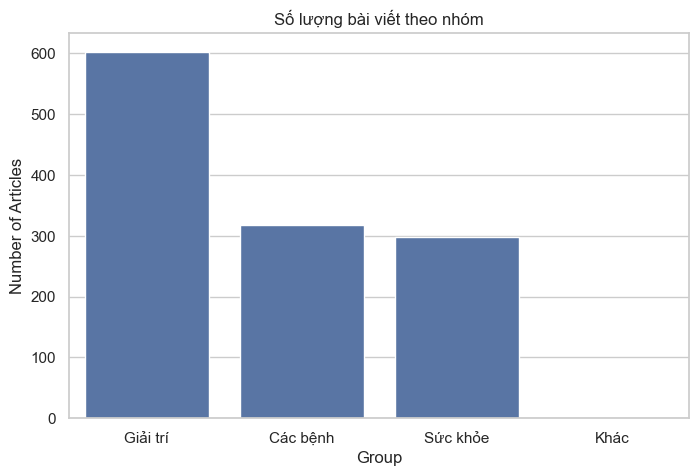

In [7]:
plt.figure(figsize=(8,5))

group_counts = df["group"].value_counts()

sns.barplot(
    x=group_counts.index,
    y=group_counts.values
)

plt.title("Số lượng bài viết theo nhóm")
plt.xlabel("Group")
plt.ylabel("Number of Articles")

plt.show()

### 3.2 Số lượng bài theo category

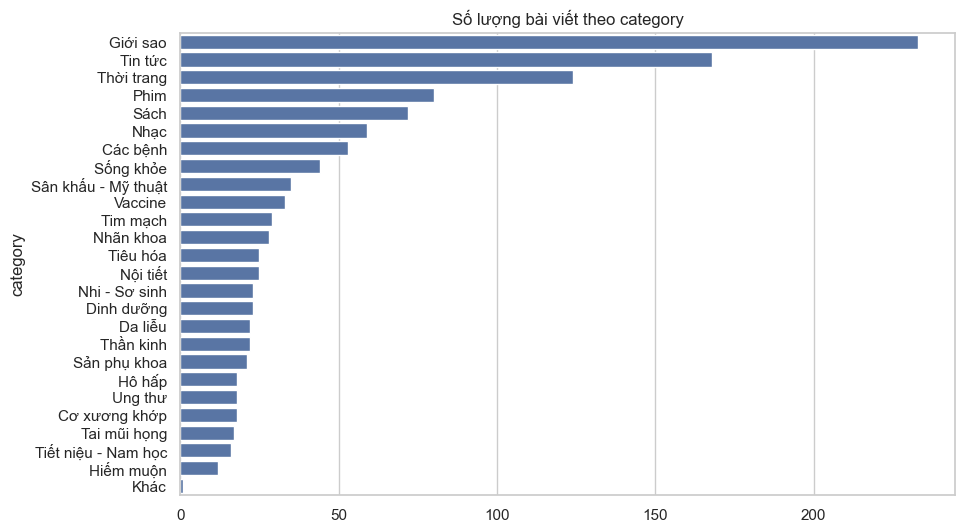

In [8]:
plt.figure(figsize=(10,6))

category_counts = df["category"].value_counts()

sns.barplot(
    y=category_counts.index,
    x=category_counts.values
)

plt.title("Số lượng bài viết theo category")

plt.show()

### 3.3 Phân bố số lượng bình luận

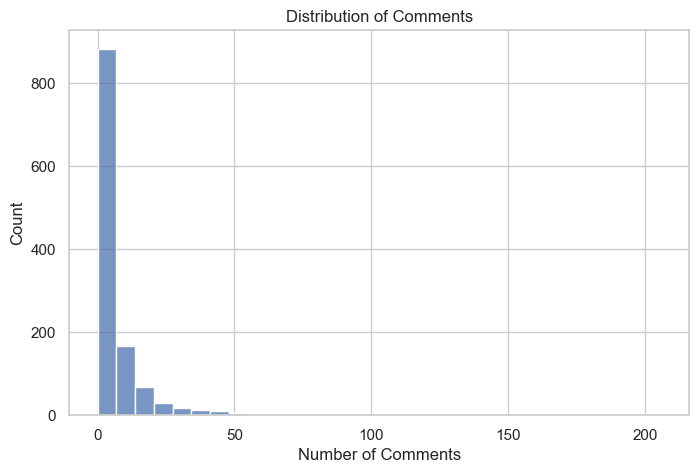

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df["nums_of_comments"], bins=30)

plt.title("Distribution of Comments")

plt.xlabel("Number of Comments")

plt.show()

### 3.4 Phân tích độ dài title và content

In [10]:
df["title_length"] = df["title"].fillna("").apply(lambda x: len(x.split()))
df["content_length"] = df["content"].fillna("").apply(lambda x: len(x.split()))

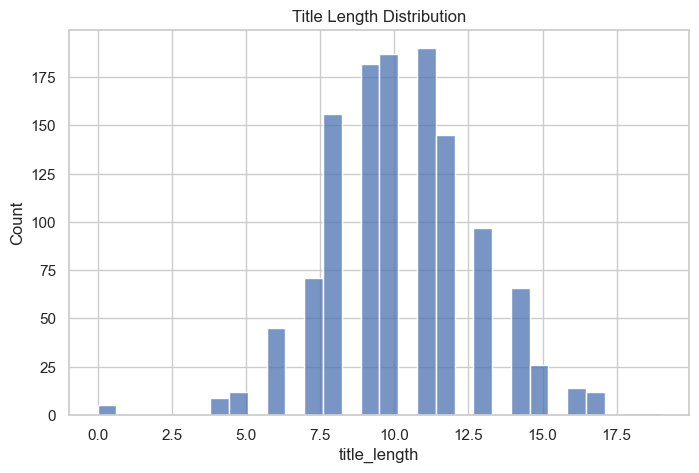

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["title_length"], bins=30)

plt.title("Title Length Distribution")

plt.show()

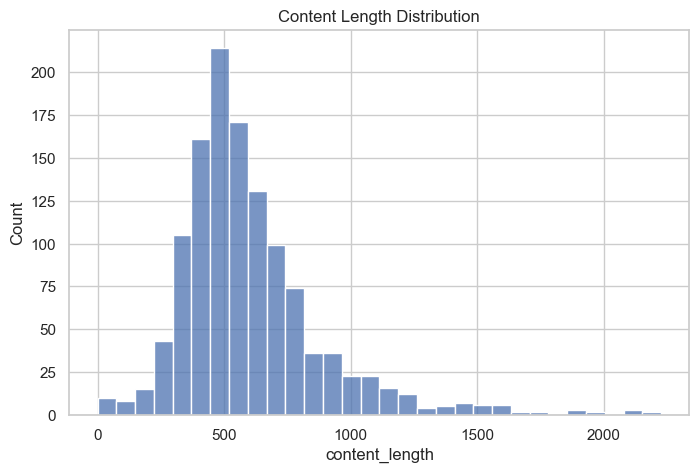

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["content_length"], bins=30)

plt.title("Content Length Distribution")

plt.show()

### 3.5 Kiểm tra bài viết bất thường

In [13]:
df.sort_values("content_length", ascending=False).head()

,title,description,date,content,thumbnail,author,tags,group,category,nums_of_comments,url,title_length,content_length
33,'Bóng đá Việt Nam' (kỳ 1): Huấn luyện cầu thủ ...,"Giai đoạn đất nước còn chiến tranh, thế hệ cầu...","Thứ hai, 26/1/2026, 10:39 (GMT+7)",Ấn phẩmBóng đá Việt Nam (1896-2025): Ký ức và ...,https://i1-giaitri.vnecdn.net/2026/01/14/dd3f2...,(Trích sáchBóng đá Việt Nam 1896-2025: Ký ức v...,"đội thể công, bóng đá việt nam, bóng đá việt n...",Giải trí,Sách,6,https://vnexpress.net/bong-da-viet-nam-ky-1-hu...,13,2228
711,'Bóng đá Việt Nam' (kỳ 2): Trận cầu mừng 25 nă...,"Đội Thể Công gỡ hòa, ghi bàn, lội ngược dòng s...","Thứ ba, 27/1/2026, 14:56 (GMT+7)",Ấn phẩmBóng đá Việt Nam (1896-2025): Ký ức và ...,https://i1-giaitri.vnecdn.net/2026/01/14/1a9ef...,"(Trích sách""Bóng đá Việt Nam (1896-2025): Ký ứ...","thể công, bóng đá việt nam, tác giả đặng hoàng...",Giải trí,Sách,4,https://vnexpress.net/bong-da-viet-nam-ky-2-tr...,13,2194
339,Đạo diễn Nguyễn Hoàng Điệp: Con trẻ sẽ đọc sác...,"Đạo diễn Nguyễn Hoàng Điệp cho rằng không ""thầ...","Thứ tư, 25/2/2026, 12:13 (GMT+7)","Bên cạnh công việc làm phim, đạo diễn Nguyễn H...",https://i1-giaitri.vnecdn.net/2026/02/13/ff4a2...,Khánh Linh,"đạo diễn nguyễn hoàng điệp, đọc sách, tủ sách ...",Giải trí,Sách,8,https://vnexpress.net/dao-dien-nguyen-hoang-di...,16,2152
683,Tự truyện Bob Iger - đằng sau thương vụ tỷ USD,"Khi đọc ''The Ride of a Lifetime'', có lúc tôi...","Thứ năm, 12/3/2026, 19:07 (GMT+7)","* Bài cảm nhận cho chuyên mục ""Cuốn sách tôi y...",https://i1-giaitri.vnecdn.net/2026/03/12/nxbtr...,Ân Nguyễn,"tự truyện của bob iger, cuốn sách tôi yêu",Giải trí,Sách,7,https://vnexpress.net/tu-truyen-bob-iger-dang-...,11,2102
961,Sách của nhà sư Thích Pháp Hòa (kỳ một): dạy c...,"Trong sách ""Lá hoa trên đường về"", nhà sư Thíc...","Thứ bảy, 21/2/2026, 10:10 (GMT+7)",SáchLá hoa trên đường vềtuyển tập những vấn đá...,https://i1-giaitri.vnecdn.net/2026/02/16/thich...,"(Trích sáchLá hoa trên đường về, công ty sáchF...",nhà sư thích pháp hòa,Giải trí,Sách,3,https://vnexpress.net/sach-cua-nha-su-thich-ph...,12,2085


## 4. Nhận xét về dữ liệu raw

Qua quá trình phân tích dữ liệu thô:

- Dataset gồm các bài viết từ hai chuyên mục:
  - Sức khỏe
  - Giải trí

- Một số vấn đề phát hiện:
  - Có thể tồn tại dữ liệu thiếu
  - Định dạng ngày chưa chuẩn
  - Văn bản chưa được chuẩn hóa
  - Có thể có bài trùng lặp

→ Vì vậy cần bước **data cleaning** để:

- Loại bỏ duplicates
- Chuẩn hóa text
- Chuẩn hóa date
- Xử lý missing values

## 5. Định hướng bài toán

Từ dữ liệu này có thể xây dựng các bài toán:

### Hướng 1: Dự đoán số lượng bình luận
- Input: title_length, content_length, category...
- Output: nums_of_comments

### Hướng 2: Phân loại bài viết
- Phân loại bài viết thuộc nhóm:
  - Sức khỏe
  - Giải trí

### Hướng 3: Phân tích xu hướng nội dung
- Phân tích chủ đề phổ biến
- Phân tích độ dài bài viết